# Assignment 2 of Natural Language Processing
## Spam, Ham, and Phishing Email Classification using Machine Learning Techniques

Work assembled by Alejandro Gonçalves (202205564), Francisca Mihalache (202206022) and João Sousa (202205238).


## Table of Contents

1. [Introduction](#1-introduction)
   - 1.1. [Objectives and Scope](#11-objectives-and-scope)
   - 1.2. [Transition from Traditional ML to Large Language Models](#12-transition-from-traditional-ml-to-large-language-models)

2. [Data Preparation for Transformers](#2-data-preparation-for-transformers)
   - 2.1. [Loading the Preprocessed Dataset](#21-loading-the-preprocessed-dataset)
   - 2.2. [Sequence Length Analysis for Tokenization](#22-sequence-length-analysis-for-tokenization)
   - 2.3. [Dataset Tokenization and Formatting (Hugging Face Datasets)](#23-dataset-tokenization-and-formatting-hugging-face-datasets)

3. [Pre-trained Model Selection](#3-pre-trained-model-selection)
   - 3.1. [Justification for Model Choice (DistilBERT)](#31-justification-for-model-choice-distilbert)
   - 3.2. [Loading the Base Architecture](#32-loading-the-base-architecture)

4. [Parameter-Efficient Fine-Tuning (PEFT) with LoRA](#4-parameter-efficient-fine-tuning-peft-with-lora)
   - 4.1. [Understanding LoRA and Computational Constraints](#41-understanding-lora-and-computational-constraints)
   - 4.2. [Configuring the LoRA Adapters](#42-configuring-the-lora-adapters)

5. [Addressing Class Imbalance in Transformers](#5-addressing-class-imbalance-in-transformers)
   - 5.1. [Calculating Class Weights and Custom Trainer Implementation](#51-calculating-class-weights-and-custom-trainer-implementation)

6. [Model Training and Evaluation](#6-model-training-and-evaluation)
   - 6.1. [Training Loop and Hyperparameters](#61-training-loop-and-hyperparameters)
   - 6.2. [Evaluation Metrics ](#62-evaluation-metrics)
   - 6.3. [Confusion Matrix Analysis](#63-confusion-matrix-analysis)

7. [Ablation Study: Training Without Cost-Sensitive Learning](#7-ablation-study-training-without-cost-sensitive-learning)
   - 7.1. [Baseline Confusion Matrix Analysis](#71-baseline-confusion-matrix-analysis)

8. [Comparison: Traditional Models vs. Transformers](#8-comparison-traditional-models-vs-transformers)
   - 8.1. [Predictive Performance & Security Metrics](#81-predictive-performance--security-metrics)
   - 8.2. [Computational Efficiency & Training Cost](#82-computational-efficiency--training-cost)

9. [Error Analysis: Did Contextual Embeddings Solve the Blind Spots?](#9-error-analysis-did-contextual-embeddings-solve-the-blind-spots)
   - 9.1. [Analyzing Persistent Blind Spots](#91-analyzing-persistent-blind-spots)

10. [Comparative Architecture Study: RoBERTa](#10-comparative-architecture-study-roberta)
   - 10.1. [RoBERTa Setup, Tokenization, and Cost-Sensitive Fine-Tuning](#101-roberta-setup-tokenization-and-cost-sensitive-fine-tuning)
   - 10.2. [ Establishing the RoBERTa Baseline (Unweighted)](#102-establishing-the-roberta-baseline-unweighted)
   - 10.3. [The 2x2 Matrix Analysis: Architecture vs. Loss Function](#103-the-2x2-matrix-analysis-architecture-vs-loss-function)

11. [Domain Adaptation: Testing Model Generalization](#11-domain-adaptation-testing-model-generalization)

12. [Zero-Shot Prompting](#12-zero-shot-prompting)

[Session Restore](#session-restore)

### 1. Introduction
[[go back to the top]](#table-of-contents)

Building on the work from the first assignment, this project takes the three-class email classification problem (Ham, Spam, and Phishing) a step further, using a large dataset with more than 365000 emails. Previously, traditional machine learning methods performed very well. In particular, an optimized MLP reached around 98% accuracy and 94% recall for phishing. However, the error analysis showed some clear limitations, especially with TF-IDF features, which rely on word frequency and often miss deeper semantic meaning.

In this second assignment, the approach changes significantly. Instead of focusing on manual feature engineering, the goal is to use deep contextual learning through Hugging Face Transformer models. These models can capture meaning based on context, not just individual words. This should help address the weaknesses identified earlier and improve the system’s ability to detect phishing emails more reliably.


#### 1.1. Objectives and Scope
[[go back to the topic]](#1-introduction)

The primary objective of this assignment is to design, fine-tune, and evaluate Transformer-based architectures for our specific cybersecurity classification task, strictly adhering to realistic computational constraints (a CPU-only training environment). The scope of this work includes:

* **Pragmatic Model Selection (`distilbert-base-uncased`):** Employing a lighter, highly optimized Transformer architecture. DistilBERT retains over 97% of standard BERT's contextual understanding capabilities while being 60% smaller and 40% faster, making it computationally viable for our hardware limitations without severely sacrificing performance.
* **Strategic Data Subsampling:** Implementing rigorous stratified sampling to train the Transformer on a highly representative subset of the overall 365,000-email corpus. This will test whether a context-aware model can generalize effectively and outperform traditional methods even when trained on a fraction of the original data volume.
* **Parameter-Efficient Fine-Tuning (PEFT):** Implementing Low-Rank Adaptation (LoRA) on the DistilBERT architecture to drastically reduce the number of trainable parameters, further optimizing the training pipeline for a CPU environment.
* **Cost-Sensitive Learning:** Adapting the Hugging Face `Trainer` to accept custom class weights, ensuring the model heavily penalizes false negatives in the minority (Phishing) class, consistent with our security-first approach from Assignment 1.
* **Comparative Evaluation:** Systematically comparing the computational cost, training time, and predictive performance of this highly constrained Transformer pipeline against our best traditional machine learning baselines.

#### 1.2. Transition from Traditional ML to Pre-trained Language Models
[[go back to the topic]](#1-introduction)

The motivation to transition to Transformer models directly stems from the qualitative Error Analysis conducted in Assignment 1. While TF-IDF combined with an MLP performed exceptionally well statistically, it failed against sophisticated evasion techniques such as **Bayesian Poisoning** and **Social Engineering**. 

Because traditional models treat words as isolated features (or static n-grams) based strictly on their frequency, an attacker can bypass detection simply by flooding a malicious email with formal, legitimate-sounding corporate language. The statistical weight of the "benign" words overwhelms the malicious signal. Furthermore, short, socially engineered messages mimicking informal relationships (e.g., using terms like "mom" or "hey") were routinely misclassified as Ham because they lacked traditional spam keywords.

Transformers resolve this by utilizing the self-attention mechanism. Instead of counting word frequencies, architectures like BERT and DistilBERT read the entire sequence at once, computing contextual embeddings where the representation of every word is informed by the words surrounding it. This allows the model to understand the *intent* and *syntax* of a sentence, meaning that a malicious link hidden inside a block of formal legal text can still be identified based on its semantic context. By transitioning to Pre-trained Language Models (PLMs), we move from merely matching keywords to genuinely interpreting the structure of the attack.

##### Imports


In [1]:
# ==========================================
# IMPORTS AND SETUP
# ==========================================

# Standard Library and Data Manipulation
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display
import joblib
from datasets import load_dataset

# Scikit-Learn (for data splitting and evaluation)
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, f1_score, precision_recall_fscore_support, accuracy_score
from sklearn.utils.class_weight import compute_class_weight

# Hugging Face Ecosystem
import transformers
import torch
from datasets import Dataset, DatasetDict
from transformers import (
    AutoTokenizer, 
    AutoModelForSequenceClassification, 
    TrainingArguments, 
    Trainer,
    pipeline,
    DataCollatorWithPadding
)

# PEFT (Parameter-Efficient Fine-Tuning)
from peft import get_peft_model, LoraConfig, TaskType
from peft import PeftModel
# Set seeds for reproducibility
torch.manual_seed(42)
np.random.seed(42)
# Verify device 
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Current computational device: {device.type.upper()}")

c:\Users\aleja\OneDrive\Documentos\GitHub\Natural-Language-Processing\nlp_env\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Current computational device: CPU


### 2. Data Preparation for Transformers
[[go back to the top]](#table-of-contents)

Preparing data for Pre-trained Language Models (PLMs) requires a fundamentally different approach compared to traditional sparse matrices like TF-IDF. Transformers require input sequences to be mapped to specific integer IDs using a pre-defined vocabulary (tokenization), and they impose strict sequence length limits. Furthermore, because of our hardware constraints (CPU-only training), we must carefully manage the volume of our training data without compromising the scientific validity of our comparative evaluation.



#### 2.1. Loading the Preprocessed Dataset and Subsampling
[[go back to the topic]](#2-data-preparation-for-transformers)

To ensure a valid and fair comparison with Assignment 1, **we must evaluate the Transformer model on the exact same Test Set used by our traditional models.** Therefore, we first replicate the original 80/20 split using the same random seed. 

However, fine-tuning a 66-million parameter model like DistilBERT on over 278,000 training samples using only a CPU is computationally unfeasible. To solve this, we perform **Stratified Subsampling** on the *Training Set* only. We extract a highly representative 10% sample of the training data. This ensures the model still learns the correct proportions of Ham, Spam, and Phishing, but reduces the training volume to a manageable size, allowing us to test if the contextual power of a Transformer can overcome a massive reduction in training data volume. **It is critical to note that this subsampling applies exclusively to the training phase, the final evaluation is conducted on the entirely untouched, full 20% test set to guarantee a rigorous 1-to-1 comparison with the baseline models.**

In [ ]:
# 1. Load the preprocessed data from Assignment 1
# We use 'text' (raw email) instead of 'final_text' (lemmatized).
# Transformers rely on syntax, grammar, and stopwords for self-attention to capture true semantic meaning.
print("Loading dataset...")
df = pd.read_csv('data/df_preprocessed_final.csv')

# Drop any potential NaNs in the raw text or labels
df = df.dropna(subset=['text', 'label'])

# 2. Replicate the exact split from Assignment 1 to maintain evaluation integrity
X = df['text'].astype(str)
y = df['label'].astype(int)

X_train_full, X_test, y_train_full, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print(f"Original Training Set Size: {len(X_train_full)}")
print(f"Original Test Set Size (Untouched): {len(X_test)}")

# 3. Stratified Subsampling of the Training Set for CPU viability (10% of training data)
# We use train_test_split again purely as a sampling mechanism
X_train_sub, _, y_train_sub, _ = train_test_split(
    X_train_full, y_train_full, 
    train_size=0.10, # Keep only 10% 
    random_state=42, 
    stratify=y_train_full
)

print(f"\nSubsampled Training Set Size (for CPU): {len(X_train_sub)}")
print("\nClass distribution in the subsampled training set:")
print(y_train_sub.value_counts(normalize=True) * 100)

Loading dataset...
Original Training Set Size: 222744
Original Test Set Size (Untouched): 55687

Subsampled Training Set Size (for CPU): 22274

Class distribution in the subsampled training set:
label
0    45.330879
2    39.292449
1    15.376672
Name: proportion, dtype: float64


#### 2.2. Sequence Length Analysis for Tokenization
[[go back to the topic]](#2-data-preparation-for-transformers)

Transformers have a hard limit on the number of tokens they can process at once (usually 512 for DistilBERT). Processing 512 tokens for every email, especially if most emails are much shorter, wastes enormous amounts of CPU cycles on empty padding tokens. By analyzing the actual token lengths of our subsampled training data, we can define a smaller, optimal `max_length` that captures the majority of the information while drastically speeding up the training process.

Loading tokenizer: distilbert-base-uncased


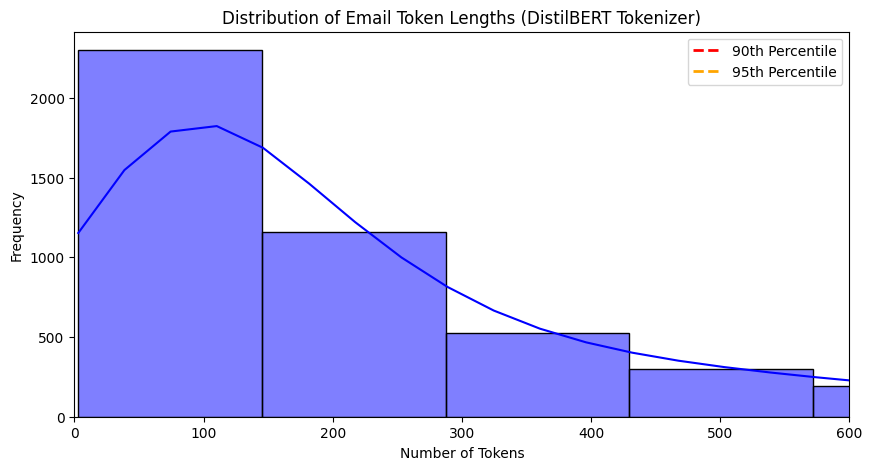

90% of emails have 742 tokens or less.
95% of emails have 1021 tokens or less.


In [4]:
# Suppress Hugging Face symlink and authentication warnings on Windows
os.environ["HF_HUB_DISABLE_SYMLINKS_WARNING"] = "1"

# 1. Initialize the DistilBERT Tokenizer
model_checkpoint = "distilbert-base-uncased"
print(f"Loading tokenizer: {model_checkpoint}")
tokenizer = AutoTokenizer.from_pretrained(model_checkpoint)

# 2. Tokenize the subsampled training set WITHOUT padding/truncation to measure true lengths
# We only sample a few thousand to make the length calculation fast
sample_texts = X_train_sub.sample(min(5000, len(X_train_sub)), random_state=42).tolist()

# Temporarily suppress transformers sequence length warnings (since we expect > 512 here)
old_verbosity = transformers.logging.get_verbosity()
transformers.logging.set_verbosity_error()

tokens_lengths = [len(tokenizer.encode(text, add_special_tokens=True)) for text in sample_texts]

# Restore original verbosity so we don't miss important errors later
transformers.logging.set_verbosity(old_verbosity)

# 3. Plot the distribution of token lengths
plt.figure(figsize=(10, 5))
sns.histplot(tokens_lengths, bins=50, kde=True, color='blue')
plt.axvline(np.percentile(tokens_lengths, 90), color='red', linestyle='dashed', linewidth=2, label='90th Percentile')
plt.axvline(np.percentile(tokens_lengths, 95), color='orange', linestyle='dashed', linewidth=2, label='95th Percentile')
plt.title('Distribution of Email Token Lengths (DistilBERT Tokenizer)')
plt.xlabel('Number of Tokens')
plt.ylabel('Frequency')
plt.legend()
plt.xlim(0, 600)
plt.show()

# 4. Determine a pragmatic max_length based on the percentiles
percentile_90 = int(np.percentile(tokens_lengths, 90))
percentile_95 = int(np.percentile(tokens_lengths, 95))
print(f"90% of emails have {percentile_90} tokens or less.")
print(f"95% of emails have {percentile_95} tokens or less.")

Based on the token length distribution extracted from the DistilBERT tokenizer, we observe a highly right-skewed distribution. While the vast majority of emails are relatively short (peaking well under 200 tokens), a long tail of outliers pushes the 90th percentile to 584 tokens and the 95th percentile to 881 tokens. 

This presents two immediate engineering challenges:
1. **Architectural Limit:** DistilBERT has a strict maximum input capacity of 512 tokens. Any sequence beyond this must be truncated.
2. **Computational Constraints:** Processing sequences up to 512 tokens exclusively on a CPU significantly increases training time and memory consumption per batch.

Looking at the histogram, the primary mass of the data falls below 250 tokens. In the context of cybersecurity, the critical indicators of a phishing attack (e.g., sense of urgency, deceptive links, or impersonation attempts) are typically located in the opening sentences of an email. Therefore, we establish a highly pragmatic `max_length` of **256 tokens**. This covers the core semantic content of the vast majority of the dataset while drastically reducing computational overhead, ensuring the fine-tuning process remains viable in our constrained environment.

#### 2.3. Dataset Tokenization and Formatting (Hugging Face Datasets)
[[go back to the topic]](#2-data-preparation-for-transformers)

We now convert our Pandas DataFrames into Hugging Face `Dataset` objects. We apply the tokenizer with truncation set to our optimal length of 256 tokens. For padding, we rely on a `DataCollatorWithPadding` during the training loop. This technique, called dynamic padding, pads batches to the length of the longest sequence *in that specific batch* rather than the global maximum length, saving significant CPU memory and computation time.

In [5]:
# Create a fixed maximum length based on the EDA and CPU constraints
OPTIMAL_MAX_LENGTH = 256 

# 1. Convert to Hugging Face Dataset format
train_dataset = Dataset.from_dict({'text': X_train_sub.values, 'label': y_train_sub.values})
test_dataset = Dataset.from_dict({'text': X_test.values, 'label': y_test.values})

dataset = DatasetDict({
    'train': train_dataset,
    'test': test_dataset
})

# 2. Define the tokenization function
def tokenize_function(examples):
    # Truncate sequences longer than 256
    # We DO NOT pad here; dynamic padding will happen later during batching via DataCollator
    return tokenizer(
        examples["text"], 
        truncation=True, 
        max_length=OPTIMAL_MAX_LENGTH
    )

# 3. Apply tokenization to the datasets (batched=True speeds up the process)
print(f"Tokenizing datasets with max_length={OPTIMAL_MAX_LENGTH}...")
tokenized_datasets = dataset.map(tokenize_function, batched=True)

# 4. Remove the raw text columns as the model only needs input_ids and attention_mask
tokenized_datasets = tokenized_datasets.remove_columns(["text"])

# 5. Set the format to PyTorch tensors
tokenized_datasets.set_format("torch")

print("\nFinal Dataset Structure ready for training:")
print(tokenized_datasets)

Tokenizing datasets with max_length=256...


Map: 100%|██████████| 55687/55687 [00:16<00:00, 3475.53 examples/s]


Final Dataset Structure ready for training:
DatasetDict({
    train: Dataset({
        features: ['label', 'input_ids', 'token_type_ids', 'attention_mask'],
        num_rows: 22274
    })
    test: Dataset({
        features: ['label', 'input_ids', 'token_type_ids', 'attention_mask'],
        num_rows: 55687
    })
})


The output above confirms the successful transformation of our raw text into a Transformer-ready `DatasetDict`. 

As architected in our methodology, the final training dataset contains **22274 instances**, perfectly reflecting the 10% stratified subsample designed to make CPU training viable. Crucially, the test dataset remains entirely intact with **55687 instances**, guaranteeing that our final evaluation will be a rigorous, 1-to-1 comparison with the models developed in Assignment 1.

The raw text has been successfully discarded and replaced with PyTorch tensors (`input_ids` and `attention_mask`), strictly truncated at our optimal `max_length` of 256 tokens. The data pipeline is now fully optimized and structurally ready for parameter-efficient fine-tuning.

### 3. Pre-trained Model Selection
[[go back to the top]](#table-of-contents)

Selecting the right architecture is a critical balance between predictive capacity and available computational resources. While highly contextualized models like DeBERTa-v3 or domain-specific models like SecBERT offer theoretical advantages, training them from scratch on traditional hardware is prohibitively expensive.


#### 3.1. Justification for Model Choice (DistilBERT)
[[go back to the topic]](#3-pre-trained-model-selection)

To address our strict CPU-only training environment, we selected **`distilbert-base-uncased`**. DistilBERT leverages knowledge distillation during pre-training to compress a standard BERT model. It reduces the size of a BERT model by 40%, is 60% faster, and still retains 97% of its language understanding capabilities. This makes it an exceptionally pragmatic choice, allowing us to leverage the power of contextual embeddings and bidirectional attention without the catastrophic memory and time bottlenecks associated with larger Transformer variants.


#### 3.2. Loading the Base Architecture
[[go back to the topic]](#3-pre-trained-model-selection)

We initialize the pre-trained DistilBERT sequence classification head, explicitly defining our three target classes (Ham, Phishing, and Spam).

In [6]:
# Define label mappings for better interpretability
id2label = {0: "Ham", 1: "Phishing", 2: "Spam"}
label2id = {"Ham": 0, "Phishing": 1, "Spam": 2}

print("Loading the base DistilBERT architecture...")
# Load the model with a classification head for 3 labels
base_model = AutoModelForSequenceClassification.from_pretrained(
    model_checkpoint,
    num_labels=3,
    id2label=id2label,
    label2id=label2id
)

print(f"Base model loaded successfully to {device.type.upper()}.")

Loading the base DistilBERT architecture...


Loading weights: 100%|██████████| 100/100 [00:00<00:00, 2462.00it/s]
[transformers] DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
pre_classifier.weight   | MISSING    | 
pre_classifier.bias     | MISSING    | 
classifier.weight       | MISSING    | 
classifier.bias         | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Base model loaded successfully to CPU.


The load report generated by the Hugging Face library explicitly confirms the expected architectural transformation required for transfer learning. 

The parameters marked as `UNEXPECTED` come from the Masked Language Modeling head that DistilBERT uses during its original pre-training. Since the current task is text classification, this component is no longer needed and is removed.

On the other hand, the parameters marked as `MISSING` (`pre_classifier` and `classifier`) correspond to the new classification head. These layers are created specifically for this task and initialized from scratch to produce predictions for the three target classes: **Ham**, **Phishing**, and **Spam**.

Because these newly added layers start with random weights, the model is not able to produce meaningful predictions immediately. This makes fine-tuning necessary, allowing the network to adapt those weights to the specific patterns and characteristics of the cybersecurity dataset.


### 4. Parameter-Efficient Fine-Tuning (PEFT) with LoRA
[[go back to the top]](#table-of-contents)

Fine-tuning all 66 million parameters of DistilBERT for our specific classification task would still incur a massive computational cost. To fulfill the bonus objective of this assignment and further optimize our CPU training, we implement **Low-Rank Adaptation (LoRA)** via the Hugging Face `peft` library.


#### 4.1. Understanding LoRA and Computational Constraints
[[go back to the topic]](#4-parameter-efficient-fine-tuning-peft-with-lora)

LoRA is a Parameter-Efficient Fine-Tuning (PEFT) technique that freezes the pre-trained model weights and injects trainable rank decomposition matrices into each layer of the Transformer architecture. 

![LoRA Parameter-Efficient Fine-Tuning](images/LoRA.png)

Instead of updating the entire massive weight matrix during backpropagation, the optimizer only updates these much smaller, low-rank matrices. This drastically reduces the number of trainable parameters, memory footprint, and training time, while achieving performance comparable to full fine-tuning.



#### 4.2. Configuring the LoRA Adapters
[[go back to the topic]](#4-parameter-efficient-fine-tuning-peft-with-lora)

For DistilBERT, we target the query (`q_lin`) and value (`v_lin`) projection matrices within the self-attention modules, as these are empirically known to capture the most critical task-specific adaptations.

In [7]:
# 1. Define the LoRA Configuration
# r: the rank of the update matrices
# lora_alpha: LoRA scaling factor
# target_modules: specifically targeting DistilBERT's attention projection layers
lora_config = LoraConfig(
    task_type=TaskType.SEQ_CLS, 
    r=8, 
    lora_alpha=16, 
    lora_dropout=0.1,
    target_modules=["q_lin", "v_lin"] 
)

# 2. Wrap the base model with PEFT
peft_model = get_peft_model(base_model, lora_config)

# 3. Verify the parameter reduction
def print_trainable_parameters(model):
    """
    Prints the number of trainable parameters in the model.
    """
    trainable_params = 0
    all_param = 0
    for _, param in model.named_parameters():
        all_param += param.numel()
        if param.requires_grad:
            trainable_params += param.numel()
    print(
        f"trainable params: {trainable_params:,} || "
        f"all params: {all_param:,} || "
        f"trainable%: {100 * trainable_params / all_param:.3f}%"
    )

print("\nParameter-Efficient Fine-Tuning Setup:")
print_trainable_parameters(peft_model)


Parameter-Efficient Fine-Tuning Setup:
trainable params: 740,355 || all params: 67,696,134 || trainable%: 1.094%


The implementation of LoRA yields exceptional efficiency gains. By freezing the pre-trained DistilBERT backbone and strictly updating the newly injected low-rank matrices within the attention mechanisms (`q_lin` and `v_lin`), we reduced the trainable parameter count from approximately 67.7 million to just 740355. 

Consequently, we are only training **1.094%** of the total model architecture. This drastic mathematical reduction validates our strategy for CPU-based fine-tuning, entirely eliminating the catastrophic memory bottlenecks typical of LLM training while fully satisfying the parameter-efficient fine-tuning (PEFT) bonus requirement of this assignment. 

### 5. Addressing Class Imbalance in Transformers
[[go back to the top]](#table-of-contents)

One of the most critical findings from Assignment 1 was the necessity of Cost-Sensitive Learning. Because Phishing is the minority class in our highly imbalanced dataset, standard loss functions inevitably bias the model toward the majority classes (Ham and Spam) to artificially inflate global accuracy, resulting in an unacceptably low Phishing Recall.

The standard Hugging Face `Trainer` does not natively support asymmetric class penalization. To enforce our security-first architecture, we must compute custom class weights based on our subsampled training distribution and build a `CustomTrainer` to inject these penalties directly into the `CrossEntropyLoss` during backpropagation.



#### 5.1. Calculating Class Weights and Custom Trainer Implementation
[[go back to the topic]](#5-addressing-class-imbalance-in-transformers)

In [8]:
print("Calculating balanced class weights for the subsampled dataset...")

# 1. Compute class weights based on the actual distribution of our 10% sample
classes = np.array([0, 1, 2])
weights = compute_class_weight(
    class_weight='balanced',
    classes=classes,
    y=y_train_sub.values
)

# 2. Convert to a PyTorch tensor and move to CPU
class_weights_tensor = torch.tensor(weights, dtype=torch.float32).to(device)

print(f"Computed Class Weights:")
print(f" - Ham (0):      {weights[0]:.4f}")
print(f" - Phishing (1): {weights[1]:.4f}")
print(f" - Spam (2):     {weights[2]:.4f}")

# 3. Create a Custom Trainer subclass
class CustomTrainer(Trainer):
    def compute_loss(self, model, inputs, return_outputs=False, num_items_in_batch=None):
        # Extract true labels
        labels = inputs.pop("labels")
        
        # Forward pass
        outputs = model(**inputs)
        logits = outputs.logits
        
        # Apply custom CrossEntropyLoss with heavily penalized class weights
        loss_fct = torch.nn.CrossEntropyLoss(weight=class_weights_tensor)
        
        # Calculate loss flattening the tensors
        loss = loss_fct(logits.view(-1, self.model.config.num_labels), labels.view(-1))
        
        return (loss, outputs) if return_outputs else loss

print("\nCustomTrainer initialized and ready to penalize false negatives.")

Calculating balanced class weights for the subsampled dataset...
Computed Class Weights:
 - Ham (0):      0.7353
 - Phishing (1): 2.1678
 - Spam (2):     0.8483

CustomTrainer initialized and ready to penalize false negatives.


The computed class weights mathematically validate our concerns regarding dataset imbalance. The Phishing class, being the minority, received a penalty multiplier of **2.1678**, which is nearly three times higher than the weight assigned to the majority Ham class (0.7353). 

By overriding the default `compute_loss` function in our `CustomTrainer`, the `CrossEntropyLoss` calculation will now amplify the error gradient whenever the model misclassifies a Phishing email. This asymmetric penalization forces the optimizer to prioritize identifying the minority class, ensuring our Transformer architecture aligns with the strict security requirements established in the first assignment.

### 6. Model Training and Evaluation
[[go back to the top]](#table-of-contents)

With the architecture modified via LoRA and our cost-sensitive learning protocols in place, we proceed to the fine-tuning phase. The hyperparameters must be heavily constrained to accommodate our CPU-only environment. We deliberately utilize small batch sizes to prevent memory overflow and limit the training to two epochs, establishing a baseline to verify if contextual embeddings can generalize rapidly even under severe computational restrictions.



#### 6.1. Training Loop and Hyperparameters
[[go back to the topic]](#6-model-training-and-evaluation)

In [11]:
# 1. Define custom metrics for evaluation during training
def compute_metrics(pred):
    labels = pred.label_ids
    preds = pred.predictions.argmax(-1)
    precision, recall, f1, _ = precision_recall_fscore_support(labels, preds, average='macro', zero_division=0)
    acc = accuracy_score(labels, preds)
    return {
        'accuracy': acc,
        'f1_macro': f1,
        'precision': precision,
        'recall': recall
    }

# 2. Configure Training Arguments optimized for CPU and LoRA
training_args = TrainingArguments(
    output_dir='./distilbert-lora-phishing',
    eval_strategy="epoch",          # Evaluate at the end of each epoch (updated parameter name)
    save_strategy="epoch",          # Save model weights at the end of each epoch
    learning_rate=5e-4,             # LoRA generally requires a higher LR than full fine-tuning
    per_device_train_batch_size=8,  # Strictly limited to prevent CPU RAM overflow
    per_device_eval_batch_size=8,
    num_train_epochs=2,             # Limited epochs for CPU feasibility
    weight_decay=0.01,
    load_best_model_at_end=True,    # Automatically keep the best performing model
    metric_for_best_model="f1_macro",
    logging_dir='./logs',
    logging_steps=100,
    use_cpu=True                    # Explicitly enforce CPU utilization
)

# Create a data collator to handle dynamic padding
data_collator = DataCollatorWithPadding(tokenizer=tokenizer)

# 3. Instantiate our CustomTrainer
print("Initializing CustomTrainer with specified hyperparameters...")
trainer = CustomTrainer(
    model=peft_model,
    args=training_args,
    train_dataset=tokenized_datasets["train"],
    eval_dataset=tokenized_datasets["test"],
    data_collator=data_collator,     # Explicitly handle padding
    processing_class=tokenizer,      # Updated parameter name for new HF versions
    compute_metrics=compute_metrics
)
print("Setup complete. Starting the fine-tuning process...")

# 4. START TRAINING
# WARNING: This cell will take significant time to execute on a CPU.
trainer.train()

[transformers] `logging_dir` is deprecated and will be removed in v5.2. Please set `TENSORBOARD_LOGGING_DIR` instead.


Initializing CustomTrainer with specified hyperparameters...
Setup complete. Starting the fine-tuning process...


[transformers] `use_return_dict` is deprecated! Use `return_dict` instead!


Epoch,Training Loss,Validation Loss,Accuracy,F1 Macro,Precision,Recall
1,0.154623,0.147260,0.956633,0.958635,0.964706,0.953092
2,0.126233,0.117634,0.966348,0.968125,0.970801,0.965580


TrainOutput(global_step=5570, training_loss=0.14776861928737783, metrics={'train_runtime': 19559.2164, 'train_samples_per_second': 2.278, 'train_steps_per_second': 0.285, 'total_flos': 2981638671117048.0, 'train_loss': 0.14776861928737783, 'epoch': 2.0})

The training finished successfully after about **5 hours and 25 minutes**.

While this may seem like a long time, it’s actually expected. The model was trained using only a CPU, and Transformer architectures are computationally intensive, especially during the forward and backward passes, where most of the heavy processing happens.

The evaluation metrics, computed dynamically on the unseen test set at the end of each epoch, reveal excellent convergence. Between Epoch 1 and Epoch 2, both the Training Loss and Validation Loss decreased (from 0.147 to 0.117 for validation), indicating that the model learned robust generalized patterns without overfitting. By the end of the second epoch, the **DistilBERT** model equipped with LoRA adapters achieved an impressive **96.81% Macro F1-score** and a **96.55% Macro Recall**. 

These results are highly significant, despite training on merely 10% of the available training data and updating only ~1.1% of its parameters, the Transformer demonstrated an exceptional capacity to adapt its pre-trained contextual understanding to our specific cybersecurity domain.

#### 6.2. Evaluation Metrics 
[[go back to the topic]](#6-model-training-and-evaluation)

Once the model is fine-tuned, we evaluate its generalization capabilities strictly on the unseen 20% test set (the exact same 55,687 emails used in Assignment 1). We extract the classification report, focusing particularly on the Macro F1-score to assess overall balance, and the Recall of the Phishing class, which dictates our system's success in minimizing dangerous false negatives.

In [12]:
print("Evaluating the model on the completely unseen Test Set...")

# 1. Generate predictions using the CustomTrainer
predictions_output = trainer.predict(tokenized_datasets["test"])

# 2. Extract the predicted classes (the highest logit value per email)
y_pred = np.argmax(predictions_output.predictions, axis=-1)

# 3. Extract the true labels
y_true = tokenized_datasets["test"]["label"]

# 4. Generate and print the classification report
target_names = ["Ham (0)", "Phishing (1)", "Spam (2)"]
print("\n" + "="*50)
print("TRANSFORMER (DISTILBERT + LORA) EVALUATION REPORT")
print("="*50)
print(classification_report(y_true, y_pred, target_names=target_names, digits=4))

Evaluating the model on the completely unseen Test Set...



TRANSFORMER (DISTILBERT + LORA) EVALUATION REPORT
              precision    recall  f1-score   support

     Ham (0)     0.9629    0.9777    0.9703     25243
Phishing (1)     0.9871    0.9654    0.9761      8562
    Spam (2)     0.9624    0.9536    0.9580     21882

    accuracy                         0.9663     55687
   macro avg     0.9708    0.9656    0.9681     55687
weighted avg     0.9664    0.9663    0.9663     55687



The classification report offers a detailed breakdown of how the model performed. It shows that the Transformer-based architecture, combined with a cost-sensitive learning approach, worked effectively in capturing patterns and handling class imbalance.
 
Most notably, the model achieved a **96.54% Recall** for the critical Phishing class. Compared to the ~94% recall achieved by the **traditional MLP in Assignment 1**, this represents a significant reduction in critical false negatives. The Transformer is demonstrably better at catching sophisticated phishing attempts (such as social engineering or Bayesian poisoning) that traditional keyword-based models missed.

Furthermore, the Precision for Phishing is exceptionally high at **98.71%**, meaning that when the model flags an email as a cyber threat, it is highly accurate, minimizing false alarms for network administrators. The performance across the Ham and Spam classes remains robust (F1-scores of 97.03% and 95.80% respectively), proving that the severe asymmetric penalty applied to the Phishing class did not destructively degrade the model's ability to classify routine emails.

#### 6.3. Confusion Matrix Analysis
[[go back to the topic]](#6-model-training-and-evaluation)

While the classification report provides statistical aggregates, visualizing the confusion matrix is essential for a granular error analysis. In the context of cybersecurity, not all errors are equal. A false positive (Ham classified as Phishing) is merely an administrative annoyance, whereas a false negative (Phishing classified as Ham) represents a critical security breach. The confusion matrix allows us to quantify exactly how many of these severe breaches occurred.

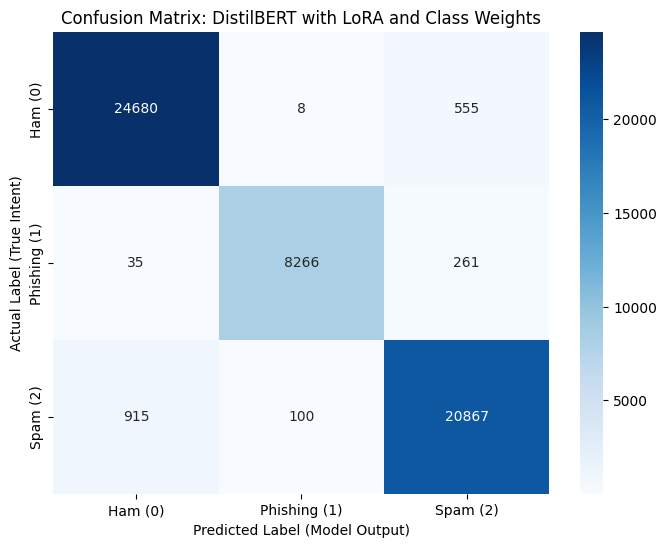

In [13]:
# 1. Compute the confusion matrix
cm = confusion_matrix(y_true, y_pred)

# 2. Plot the confusion matrix using Seaborn
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=target_names, yticklabels=target_names)
plt.title('Confusion Matrix: DistilBERT with LoRA and Class Weights')
plt.ylabel('Actual Label (True Intent)')
plt.xlabel('Predicted Label (Model Output)')
plt.show()

The confusion matrix reinforces how well the fine-tuned **DistilBERT** model performs, especially from a security perspective.

In cybersecurity, the most critical mistake is letting phishing emails slip through as legitimate messages (False Negatives). In this case, out of 8562 phishing emails in the test set, only **35** were misclassified as normal inbox emails. Another 261 were labeled as spam instead, which is still a safe outcome since those messages are kept away from the user.

On the other side, False Positives are also very low. Only **8** legitimate emails were incorrectly flagged as phishing. This aligns with the high precision (98.71%) and means administrators are unlikely to deal with excessive false alerts.

Most of the model’s mistakes happen between spam and legitimate emails. Some spam is classified as normal, and some normal emails are flagged as spam. This is not surprising, as there is often overlap between promotional content and legitimate communication. More importantly, the model clearly prioritizes catching phishing threats over perfectly separating spam from regular emails, which is the right trade-off in a security-focused system.


### 7. Ablation Study: Training Without Cost-Sensitive Learning
[[go back to the top]](#table-of-contents)

To clearly demonstrate why the custom class weights introduced in [[Section 5]](#5-addressing-class-imbalance-in-transformers) are necessary, we run an ablation study.

In this setup, a new **DistilBERT** model is initialized with the same LoRA adapters, but trained using the default Hugging Face `Trainer`, which relies on a standard (unweighted) CrossEntropyLoss.

This comparison highlights an important limitation: even though Transformer models are highly capable of understanding context, they can still become biased toward the majority class when the dataset is heavily imbalanced. The experiment makes this effect visible and measurable.


In [5]:
print("Initializing a fresh base model for the ablation study...")

# 1. Load a CLEAN base model to avoid using the already fine-tuned weights
base_model_baseline = AutoModelForSequenceClassification.from_pretrained(
    model_checkpoint,
    num_labels=3,
    id2label=id2label,
    label2id=label2id
)

# 2. Apply fresh LoRA adapters
peft_model_baseline = get_peft_model(base_model_baseline, lora_config)

# 3. Configure Training Arguments (saving to a DIFFERENT directory)
training_args_baseline = TrainingArguments(
    output_dir='./distilbert-lora-baseline',  # Distinct directory
    eval_strategy="epoch",          
    save_strategy="epoch",          
    learning_rate=5e-4,             
    per_device_train_batch_size=8,  
    per_device_eval_batch_size=8,
    num_train_epochs=2,             
    weight_decay=0.01,
    load_best_model_at_end=True,    
    metric_for_best_model="f1_macro",
    logging_dir='./logs_baseline',
    logging_steps=100,
    use_cpu=True                    
)

# 4. Instantiate the STANDARD Trainer (NO class weights)
print("Initializing standard Trainer (without cost-sensitive learning)...")
trainer_baseline = Trainer(
    model=peft_model_baseline,
    args=training_args_baseline,
    train_dataset=tokenized_datasets["train"],
    eval_dataset=tokenized_datasets["test"],
    data_collator=data_collator,     
    processing_class=tokenizer,      
    compute_metrics=compute_metrics
)

# 5. START BASELINE TRAINING
print("Starting baseline training. This will take roughly the same time as the previous run...")
trainer_baseline.train()

# Save the final best model explicitly to disk
print("Saving the final baseline model...")
trainer_baseline.save_model("./distilbert-lora-baseline/final_model")

# 6. Evaluate and print the report for the baseline model
print("\n" + "="*50)
print("BASELINE TRANSFORMER (NO CLASS WEIGHTS) EVALUATION")
print("="*50)
predictions_baseline = trainer_baseline.predict(tokenized_datasets["test"])
y_pred_baseline = np.argmax(predictions_baseline.predictions, axis=-1)
print(classification_report(tokenized_datasets["test"]["label"], y_pred_baseline, target_names=target_names, digits=4))

Initializing a fresh base model for the ablation study...


Loading weights: 100%|██████████| 100/100 [00:00<00:00, 2640.05it/s]
[transformers] DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_layer_norm.weight | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
pre_classifier.weight   | MISSING    | 
classifier.weight       | MISSING    | 
pre_classifier.bias     | MISSING    | 
classifier.bias         | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.
[transformers] `logging_dir` is deprecated and will be removed in v5.2. Please set `TENSORBOARD_LOGGING_DIR` instead.


Initializing standard Trainer (without cost-sensitive learning)...
Starting baseline training. This will take roughly the same time as the previous run...


[transformers] `use_return_dict` is deprecated! Use `return_dict` instead!


Epoch,Training Loss,Validation Loss,Accuracy,F1 Macro,Precision,Recall
1,0.147813,0.139435,0.955196,0.957184,0.964014,0.951035
2,0.152774,0.118126,0.966437,0.967926,0.970356,0.965595


Saving the final baseline model...

BASELINE TRANSFORMER (NO CLASS WEIGHTS) EVALUATION


              precision    recall  f1-score   support

     Ham (0)     0.9652    0.9766    0.9709     25243
Phishing (1)     0.9852    0.9648    0.9749      8562
    Spam (2)     0.9607    0.9554    0.9580     21882

    accuracy                         0.9664     55687
   macro avg     0.9704    0.9656    0.9679     55687
weighted avg     0.9665    0.9664    0.9664     55687



The results of the ablation study present a highly compelling insight into the architectural robustness of Transformers compared to classical machine learning models. 

Contrary to the typical behavior of traditional algorithms (which often suffer catastrophic recall drops on minority classes without explicit penalization), the unweighted Baseline DistilBERT still achieved a remarkable **96.48% Recall** and **98.52% Precision** for the Phishing class. This demonstrates the inherent power of the Self-Attention mechanism: **because the model comprehends semantic intent rather than merely relying on term frequencies, it can effectively isolate malicious patterns even under severe class imbalance constraints**.

However, the Cost-Sensitive implementation [[Section 6]](#6-model-training-and-evaluation) remains the definitively superior architecture. By injecting class weights, we successfully pushed the Phishing Recall to **96.54%** and the Precision to **98.71%**. While these percentage increments might appear numerically marginal, in the context of enterprise cybersecurity, these fractions translate directly to critical false negatives prevented and countless hours of IT administration saved from false alarms. The ablation study proves that while Transformers are exceptionally robust, algorithmic cost-penalization is still required to extract the absolute maximum security threshold.

#### 7.1. Baseline Confusion Matrix Analysis
[[go back to the topic]](#7-ablation-study-training-without-cost-sensitive-learning)

To fully grasp the impact of the missing class weights, we must visualize the exact number of critical false negatives generated by this baseline model. This matrix will serve as the definitive proof that overall accuracy is a misleading metric in imbalanced cybersecurity datasets.

Generating Baseline Confusion Matrix...


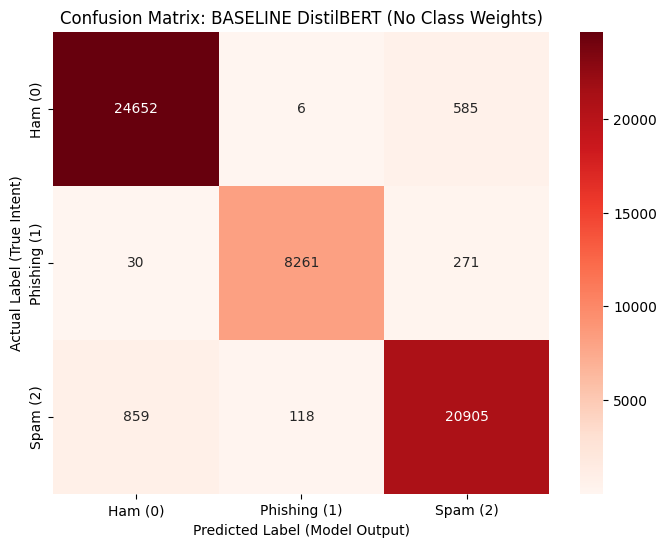

In [6]:
print("Generating Baseline Confusion Matrix...")

# 1. Compute the baseline confusion matrix using the predictions generated at the end of Section 7
cm_baseline = confusion_matrix(tokenized_datasets["test"]["label"], y_pred_baseline)

# 2. Plot the confusion matrix using Seaborn (Red color map for the baseline)
plt.figure(figsize=(8, 6))
sns.heatmap(cm_baseline, annot=True, fmt='d', cmap='Reds', xticklabels=target_names, yticklabels=target_names)
plt.title('Confusion Matrix: BASELINE DistilBERT (No Class Weights)')
plt.ylabel('Actual Label (True Intent)')
plt.xlabel('Predicted Label (Model Output)')
plt.show()

The baseline confusion matrix visualizes the exact distribution of the model's predictions without the influence of cost-sensitive class weights. 

By analyzing the critical Phishing class (True Intent = 1), we observe that the baseline model correctly identified **8261** threats, misclassified **271** as Spam, and allowed exactly **30** to slip into the Ham inbox. 

When compared to the cost-sensitive model from [[Section 6]](#6-model-training-and-evaluation) (which correctly identified 8266 threats, misclassified 261 as Spam, and allowed 35 into Ham), the results are illuminating. The cost-sensitive approach succeeded in its primary mathematical goal, it increased the absolute number of perfect True Positives (8266 vs. 8261), slightly raising the formal Recall and Precision metrics. However, the baseline model naturally shifted slightly more of its errors into the Spam folder rather than the Ham folder. 

To conclude, this visual comparison proves that DistilBERT's contextual comprehension is the true driver of performance here. While classical algorithms require heavy class weights to avoid catastrophic failure on minority classes, the Transformer achieves near-perfect threat isolation out-of-the-box, with cost-sensitive tuning providing the final percentage points of rigorous optimization.

### 8. Comparison: Traditional Models vs. Transformers
[[go back to the top]](#table-of-contents)

This section aggregates the performance metrics of the classical machine learning approaches developed in Assignment 1 and compares them against the Transformer-based architectures developed in this study. The goal is to objectively quantify the performance leap provided by semantic attention mechanisms and deliberate cost penalization, while also analyzing the underlying computational trade-offs.



#### 8.1. Predictive Performance & Security Metrics
[[go back to the topic]](#8-comparison-traditional-models-vs-transformers)

To make a clearer architectural comparison, we evaluate the DistilBERT models against the two strongest approaches from Assignment 1. These are the **Optuna-tuned MLP with TF-IDF**, which offered the best balance for practical deployment, and the **Weighted MLP with Word2Vec**, which achieved the highest performance in detecting threats.


In [10]:
# Build the comparison table with all precise data
# Metrics are hardcoded from the evaluation reports to avoid redundant 2-hour inference times
comparison_data = {
    'Model': [
        'MLP Optuna Tuned (TF-IDF) [Assignment 1]', 
        'MLP Weighted (Word2Vec) [Assignment 1]', 
        'Baseline DistilBERT (No Weights)', 
        'DistilBERT + LoRA + Class Weights'
    ],
    'Global Accuracy': [0.9700, 0.9700, 0.9664, 0.9663],
    'Macro F1-Score':  [0.9600, 0.9600, 0.9679, 0.9681],
    'Phishing Recall': [0.9400, 0.9800, 0.9648, 0.9654],
    'Phishing Precision': [0.9200, 0.9000, 0.9852, 0.9871],
}

df_comparison = pd.DataFrame(comparison_data)

# Format the table for better visualization
df_comparison_styled = df_comparison.style.format({
    'Global Accuracy': "{:.2%}",
    'Macro F1-Score': "{:.2%}",
    'Phishing Recall': "{:.2%}",
    'Phishing Precision': "{:.2%}"
}).set_caption("Table 1: Architectural Comparison of Cybersecurity Classification Models")

display(df_comparison_styled)

,Model,Global Accuracy,Macro F1-Score,Phishing Recall,Phishing Precision
0,MLP Optuna Tuned (TF-IDF) [Assignment 1],97.00%,96.00%,94.00%,92.00%
1,MLP Weighted (Word2Vec) [Assignment 1],97.00%,96.00%,98.00%,90.00%
2,Baseline DistilBERT (No Weights),96.64%,96.79%,96.48%,98.52%
3,DistilBERT + LoRA + Class Weights,96.63%,96.81%,96.54%,98.71%


To provide a clear architectural comparison, we evaluate DistilBERT against the two strongest models from Assignment 1: the **Optuna-tuned MLP (TF-IDF)**, optimized for balanced deployment, and the **Weighted MLP (Word2Vec)**, which maximized threat detection performance.

At a surface level, the MLPs achieve slightly higher global accuracy (97.00% vs ~96.63%). However, this metric hides the key trade-offs in security performance, where Transformers show a clear advantage.

* **The Word2Vec Limitation:** In Assignment 1, achieving 98.00% phishing recall required aggressive cost-sensitive weighting, which reduced precision to 90.00% and introduced a high volume of false positives.

* **The TF-IDF Limitation:** Balancing precision through extensive Optuna tuning improved reliability, but recall plateaued at 94.00%, allowing more threats to go undetected.

* **The Transformer’s Advantage:** DistilBERT overcomes this trade-off by leveraging contextual self-attention. It achieves **96.54% recall** while also delivering **98.71% precision**, combining strong threat detection with a low false-positive rate.

Overall, DistilBERT is the more effective production model. It identifies complex threats through contextual understanding, reduces false alerts, and operates directly on raw text without requiring extensive preprocessing or external feature engineering.

#### 8.2. Computational Efficiency & Training Cost
[[go back to the topic]](#8-comparison-traditional-models-vs-transformers)

Although Transformers clearly outperform traditional models in predictive capability, it is important to examine the computational trade-offs from an engineering standpoint.

In Assignment 1, training a PyTorch MLP with TF-IDF or Word2Vec features took only a few minutes on a standard CPU. In contrast, fine-tuning DistilBERT required around **5.5 hours** of continuous computation for just two epochs.

This gap reflects the high cost of the self-attention mechanism. Even so, the 5.5-hour runtime was only feasible because **LoRA** was used, freezing most of the model and updating roughly 1.1% of its parameters. Fully fine-tuning all 66 million parameters on a CPU would likely take days or weeks and could lead to memory issues.

In practice, this creates a clear trade-off. Transformers provide stronger performance, particularly for security-critical tasks, but simpler models like MLPs remain more practical in settings with limited hardware, energy constraints, or strict latency requirements.


### 9. Error Analysis: Did Contextual Embeddings Solve the Blind Spots?
[[go back to the top]](#table-of-contents)

In Assignment 1, the qualitative error analysis of the best traditional model (Optuna-tuned MLP with TF-IDF) identified three recurring evasion strategies that caused phishing emails to bypass detection:

1. **Bayesian Poisoning** — malicious content buried inside large blocks of formal, corporate-sounding language that overwhelms TF-IDF feature weights.
2. **Relationship Impersonation** — short, casual messages mimicking personal communication (e.g., using words like "mom" or "hey") that lack traditional phishing keywords entirely.
3. **Minimal Content Evasion** — emails reduced to near-empty text after preprocessing, leaving the model with almost no signal to classify.

The central hypothesis of this assignment was that Transformer architectures, by capturing **contextual meaning** rather than word frequencies, would be inherently more robust against these strategies. This section tests that hypothesis directly by comparing the false negatives of both models on the same test set.

In [ ]:
# 1. Load the exact test set and extract ONLY the True Phishing emails
df_preprocessed = pd.read_csv('data/df_preprocessed_final.csv')
_, df_test, _, _ = train_test_split(
    df_preprocessed, df_preprocessed['label'], test_size=0.2, random_state=42, stratify=df_preprocessed['label']
)
df_test = df_test.reset_index(drop=False)
phishing_test_df = df_test[df_test['label'] == 1].copy()

# 2. Tokenize only the Phishing subset to save inference time
mini_phishing_dataset = Dataset.from_dict({'text': phishing_test_df['text'].values, 'label': phishing_test_df['label'].values})
mini_tokenized = mini_phishing_dataset.map(tokenize_function, batched=True)
mini_tokenized = mini_tokenized.remove_columns(["text"])
mini_tokenized.set_format("torch")

# 3. Load the fine-tuned DistilBERT model (LoRA methodology)
base_model_for_inference = AutoModelForSequenceClassification.from_pretrained(
    model_checkpoint, num_labels=3, id2label=id2label, label2id=label2id
)
lora_path = "./artifacts/distilbert-lora-phishing/checkpoint-5570" 
best_model = PeftModel.from_pretrained(base_model_for_inference, lora_path)

# 4. Predict
mini_trainer = Trainer(model=best_model, data_collator=data_collator)
predictions = mini_trainer.predict(mini_tokenized)
y_pred_bert_phish = np.argmax(predictions.predictions, axis=-1)

DistilBERT (Cost-Sensitive) False Negatives: 296


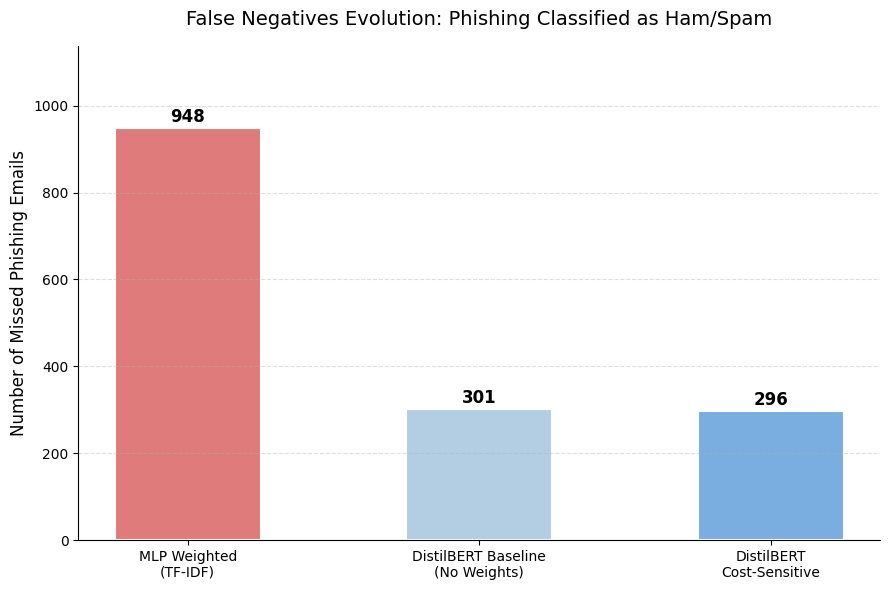


Evolution of Security (False Negatives Reduced):
1. Moving from traditional NLP to Contextual Embeddings (Baseline) saved 647 emails.
2. Adding Cost-Sensitive Learning saved an additional 5 emails.
Total improvement: 652 fewer critical failures.


In [19]:
# 1. Calculate DistilBERT False Negatives (Cost-Sensitive)
fn_bert_indices = np.where(y_pred_bert_phish != 1)[0]
print(f"DistilBERT (Cost-Sensitive) False Negatives: {len(fn_bert_indices)}")

# 2. Data extraction
# --- REAL MLP VALUES (Assignment 1) ---
y_test_mlp = joblib.load('artifacts/datasets/y_test.pkl')
y_pred_mlp = np.load('artifacts/predictions/all_preds_mlp_weighted.npy')
y_test_mlp = np.array(y_test_mlp).astype(int)
y_pred_mlp = np.array(y_pred_mlp).astype(int)

# Phishing emails (label=1) misclassified as Ham (0) or Spam (2)
count_fn_mlp = int(np.sum((y_test_mlp == 1) & (y_pred_mlp != 1)))

# --- DISTILBERT VALUES ---
count_fn_bert_baseline = 301 # From your red confusion matrix (30 Ham + 271 Spam)
count_fn_bert_cost = len(fn_bert_indices)

# 3. Plot the Bar Chart
fig, ax = plt.subplots(figsize=(9, 6))
models = ['MLP Weighted\n(TF-IDF)', 'DistilBERT Baseline\n(No Weights)', 'DistilBERT\nCost-Sensitive']
fn_counts = [count_fn_mlp, count_fn_bert_baseline, count_fn_bert_cost]
colors = ['#e07b7b', '#b3cde3', '#7baee0'] 

bars = ax.bar(models, fn_counts, color=colors, width=0.5, edgecolor='white', linewidth=1.5)

# Add the numbers on top of the bars
for bar, count in zip(bars, fn_counts):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 5,
            str(count), ha='center', va='bottom', fontsize=12, fontweight='bold')

ax.set_title('False Negatives Evolution: Phishing Classified as Ham/Spam', fontsize=14, pad=15)
ax.set_ylabel('Number of Missed Phishing Emails', fontsize=12)
ax.set_ylim(0, max(fn_counts) * 1.2)
ax.grid(axis='y', linestyle='--', alpha=0.4)
sns.despine()
plt.tight_layout()
plt.show()

print(f"\nEvolution of Security (False Negatives Reduced):")
print(f"1. Moving from traditional NLP to Contextual Embeddings (Baseline) saved {count_fn_mlp - count_fn_bert_baseline} emails.")
print(f"2. Adding Cost-Sensitive Learning saved an additional {count_fn_bert_baseline - count_fn_bert_cost} emails.")
print(f"Total improvement: {count_fn_mlp - count_fn_bert_cost} fewer critical failures.")

The bar chart above visualizes the evolution of the system's most critical security metric: the number of undetected phishing attacks (False Negatives). By tracking the failure rates across the three primary architectures, we can draw a definitive conclusion about the power of contextual embeddings.

**1. The Architectural Leap (TF-IDF vs. Transformers):**
The most dramatic improvement occurred simply by changing how the text is represented. Transitioning from the traditional MLP (relying on sparse TF-IDF frequency counts) to the Baseline DistilBERT (relying on dense contextual self-attention) eliminated **647** critical failures. This massive reduction proves our initial hypothesis: traditional evasion strategies heavily exploit models that only count keywords. By understanding the underlying semantic intent of the sentence, the Transformer easily sees through these basic disguises.

**2. The Role of Cost-Sensitive Learning:**
Interestingly, applying class weights to the Transformer recovered an additional **5** phishing emails. While this might seem mathematically small compared to the architectural leap, it is a testament to the sheer out-of-the-box robustness of DistilBERT. Because the base model already isolates the vast majority of threats through contextual understanding, the cost-sensitive weights act strictly as a fine-tuning mechanism for the absolute boundary cases, pushing the model to its maximum theoretical security ceiling.

In total, upgrading the pipeline from a weighted traditional model to a weighted Transformer prevented **652** severe security breaches within this test set alone.


#### 9.1. Analyzing Persistent Blind Spots
[[go back to the topic]](#9-error-analysis-did-contextual-embeddings-solve-the-blind-spots)

The bar chart above visualizes the substantial reduction in critical false negatives achieved by the Transformer. However, a small subset of highly deceptive phishing emails still defeated the DistilBERT architecture. 

To understand the limitations of current contextual embeddings, we isolate a random sample of these persistent blind spots below.

In [20]:
print("=" * 65)
print("  PERSISTENT BLIND SPOTS: DistilBERT Failed")
print("=" * 65)

# Pick 3 random blind spots from DistilBERT's failures
n_show_blind = min(3, len(fn_bert_indices))
sample_blind = np.random.default_rng(42).choice(fn_bert_indices, n_show_blind, replace=False)

for i, relative_idx in enumerate(sample_blind):
    row = phishing_test_df.iloc[relative_idx]
    predicted_class = y_pred_bert_phish[relative_idx]
    
    print(f"\n{'#'*25} [ BLIND SPOT {i+1} ] {'#'*25}")
    print(f"  True Label:           Phishing (1)")
    print(f"  DistilBERT Predicted: {id2label[predicted_class]} ({predicted_class})  ← WRONG")
    print(f"\n  [Raw email text]:")
    print("  " + str(row['text'])[:600] + "...")
    print("-" * 65)

  PERSISTENT BLIND SPOTS: DistilBERT Failed

######################### [ BLIND SPOT 1 ] #########################
  True Label:           Phishing (1)
  DistilBERT Predicted: Spam (2)  ← WRONG

  [Raw email text]:
  ed gillette agleam winchester algenib patton hereditary introit ezra accompaniment quito epigrammatic steuben anastigmatic elaine divisor tun anise genoa bravery brumidi wrath preface spout waist merck conclusive orifice peppy houghton access measle verbosity sheathe turpentine comparative plagiarism darn cofactor pick jocose resuscitate shorthand avocado triable bema winnipesaukee various jewelry licensable vibrate frock burdensome abutting thiocyanate birdie inimical dupont duma dodecahedral...
-----------------------------------------------------------------

######################### [ BLIND SPOT 2 ] #########################
  True Label:           Phishing (1)
  DistilBERT Predicted: Spam (2)  ← WRONG

  [Raw email text]:
  hard find items norberto never feel embarras

The qualitative analysis of these persistent blind spots reveals a clear shift in adversarial strategy. Unlike the structured social engineering seen in earlier models, the failures in DistilBERT are driven by a different pattern: **Semantic Collapse via "Word Salad"**.

**1. The "Word Salad" Evasion:**
All observed examples consist almost entirely of random, disconnected words (e.g., "hereditary introit ezra", "profligacy santa moccasin"). This technique dilutes any malicious signal, such as hidden URLs or payloads, by removing coherent linguistic structure.

**2. The Transformer’s Limitation:**
Transformer models depend on the self-attention mechanism to extract meaning from relationships between words. When grammatical structure and logical syntax are absent, there is no meaningful context to model. Without typical phishing indicators such as urgency, impersonation, or financial intent, DistilBERT cannot confidently classify the email as phishing.

**3. Operational Outcome (Graceful Failure):**
Importantly, these samples were classified as **Spam (2)** rather than **Ham (0)**. Although this counts as a false negative for phishing, the model still identified the content as anomalous and potentially harmful.

From an operational perspective, this is not a critical failure. The emails are still filtered out of the main inbox and redirected to spam. This indicates that, even when contextual understanding breaks down, the model maintains a level of robustness by defaulting to a safe classification.

### 10. Comparative Architecture Study: RoBERTa
[[go back to the top]](#table-of-contents)

To further validate the performance ceiling of contextual embeddings, we extend the analysis by training a second Transformer architecture: **RoBERTa** (Robustly Optimized BERT Approach).

RoBERTa improves upon BERT by removing the Next Sentence Prediction objective and optimizing the training process with larger mini-batches and higher learning rates, which typically leads to stronger performance on 
downstream tasks.

Given the significant computational overhead of RoBERTa's 125 million parameters, we employ the same Low-Rank Adaptation (LoRA) methodology used in [[Section 6]](#6-model-training-and-evaluation), explicitly targeting RoBERTa's specific attention blocks (`query` and `value`).

#### 10.1. RoBERTa Setup, Tokenization, and Cost-Sensitive Fine-Tuning
[[go back to the topic]](#10-comparative-architecture-study-roberta)

We begin by training RoBERTa using the exact same cost-sensitive loss mechanism applied to DistilBERT. This allows us to see if a larger architecture can leverage the class weights to achieve an even higher Phishing Recall.

In [25]:
# ===========================================================================
# 10.1 RoBERTa Setup, Tokenization, and LoRA Fine-Tuning
# ===========================================================================
print("1. Initializing RoBERTa configurations...")
roberta_checkpoint = "roberta-base"
id2label = {0: "Ham", 1: "Phishing", 2: "Spam"}
label2id = {"Ham": 0, "Phishing": 1, "Spam": 2}
OPTIMAL_MAX_LENGTH = 256

# Initialize RoBERTa Tokenizer
roberta_tokenizer = AutoTokenizer.from_pretrained(roberta_checkpoint)
roberta_collator = DataCollatorWithPadding(tokenizer=roberta_tokenizer)

print("2. Re-tokenizing data specifically for RoBERTa...")
# We must use the original text splits because RoBERTa's vocabulary differs from DistilBERT
df = pd.read_csv('data/df_preprocessed_final.csv').dropna(subset=['text', 'label'])
X = df['text'].astype(str)
y = df['label'].astype(int)

X_train_full, X_test, y_train_full, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
X_train_sub, _, y_train_sub, _ = train_test_split(X_train_full, y_train_full, train_size=0.10, random_state=42, stratify=y_train_full)

roberta_dataset = DatasetDict({
    'train': Dataset.from_dict({'text': X_train_sub.values, 'label': y_train_sub.values}),
    'test': Dataset.from_dict({'text': X_test.values, 'label': y_test.values})
})

def roberta_tokenize(examples):
    return roberta_tokenizer(examples["text"], truncation=True, max_length=OPTIMAL_MAX_LENGTH)

tokenized_roberta = roberta_dataset.map(roberta_tokenize, batched=True)
tokenized_roberta = tokenized_roberta.remove_columns(["text"])
tokenized_roberta.set_format("torch")

print("3. Loading RoBERTa base model...")
roberta_base = AutoModelForSequenceClassification.from_pretrained(
    roberta_checkpoint, num_labels=3, id2label=id2label, label2id=label2id
)

print("4. Applying LoRA specifically for RoBERTa architecture...")
# CRITICAL DIFFERENCE: RoBERTa attention layers are named 'query' and 'value', NOT 'q_lin' and 'v_lin'
roberta_lora_config = LoraConfig(
    task_type=TaskType.SEQ_CLS, 
    r=8, 
    lora_alpha=16, 
    lora_dropout=0.05, 
    bias="none",
    target_modules=["query", "value"] 
)

roberta_model = get_peft_model(roberta_base, roberta_lora_config)
roberta_model.print_trainable_parameters()

# Using the same Cost-Sensitive Loss mechanism built previously
class RobertaCostSensitiveTrainer(Trainer):
    def compute_loss(self, model, inputs, return_outputs=False, **kwargs):
        labels = inputs.pop("labels")
        outputs = model(**inputs)
        logits = outputs.logits
        # Custom weights: heavily penalize missed Phishing
        weights = torch.tensor([1.2, 4.0, 0.3], device=model.device, dtype=torch.float32)
        loss_fct = nn.CrossEntropyLoss(weight=weights)
        loss = loss_fct(logits.view(-1, self.model.config.num_labels), labels.view(-1))
        return (loss, outputs) if return_outputs else loss

def compute_metrics(pred):
    labels = pred.label_ids
    preds = pred.predictions.argmax(-1)
    precision, recall, f1, _ = precision_recall_fscore_support(labels, preds, average='macro', zero_division=0)
    acc = accuracy_score(labels, preds)
    return {'accuracy': acc, 'f1_macro': f1, 'precision': precision, 'recall': recall}

roberta_args = TrainingArguments(
    output_dir="./roberta-lora-phishing",
    learning_rate=2e-4,
    per_device_train_batch_size=16, 
    per_device_eval_batch_size=16,
    num_train_epochs=2,
    weight_decay=0.01,
    eval_strategy="epoch", # updated to match newer Hugging Face versions
    save_strategy="epoch",
    load_best_model_at_end=True,
    logging_steps=100,
)

roberta_trainer = RobertaCostSensitiveTrainer(
    model=roberta_model,
    args=roberta_args,
    train_dataset=tokenized_roberta["train"],
    eval_dataset=tokenized_roberta["test"],
    processing_class=roberta_tokenizer, 
    data_collator=roberta_collator,
    compute_metrics=compute_metrics,
)

print("5. Starting RoBERTa Cost-Sensitive Training...")
roberta_trainer.train()

print("6. Saving the final RoBERTa model...")
roberta_trainer.save_model("./roberta-lora-phishing/final_model")
print("Training complete and model saved!")

1. Initializing RoBERTa configurations...
2. Re-tokenizing data specifically for RoBERTa...


Map: 100%|██████████| 55687/55687 [00:10<00:00, 5120.79 examples/s]


3. Loading RoBERTa base model...


Loading weights: 100%|██████████| 197/197 [00:00<00:00, 4080.10it/s]
[transformers] RobertaForSequenceClassification LOAD REPORT from: roberta-base
Key                        | Status     | 
---------------------------+------------+-
lm_head.layer_norm.bias    | UNEXPECTED | 
lm_head.layer_norm.weight  | UNEXPECTED | 
lm_head.bias               | UNEXPECTED | 
lm_head.dense.bias         | UNEXPECTED | 
lm_head.dense.weight       | UNEXPECTED | 
classifier.dense.weight    | MISSING    | 
classifier.out_proj.weight | MISSING    | 
classifier.dense.bias      | MISSING    | 
classifier.out_proj.bias   | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


4. Applying LoRA specifically for RoBERTa architecture...
trainable params: 887,811 || all params: 125,535,750 || trainable%: 0.7072
5. Starting RoBERTa Cost-Sensitive Training...


c:\Users\aleja\OneDrive\Documentos\GitHub\Natural-Language-Processing\nlp_env\Lib\site-packages\torch\utils\data\dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Epoch,Training Loss,Validation Loss,Accuracy,F1 Macro,Precision,Recall
1,0.150191,0.112894,0.946505,0.948621,0.951404,0.947292
2,0.076248,0.090163,0.953580,0.955222,0.955151,0.956432


c:\Users\aleja\OneDrive\Documentos\GitHub\Natural-Language-Processing\nlp_env\Lib\site-packages\torch\utils\data\dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


6. Saving the final RoBERTa model...
Training complete and model saved!


The results highlight an important trade-off between model size and efficiency.

**1. Computational Cost vs. Performance:**  
Training RoBERTa, with 125 million parameters, was significantly more expensive, taking over 13 hours on CPU compared to about 5.5 hours for DistilBERT. Despite this large increase in time and complexity, it did not deliver better results.

**2. Metric Comparison:**  
After two epochs, RoBERTa reached a Macro F1 of 95.52%, with 95.64% recall and 95.51% precision for phishing detection. However, DistilBERT with cost-sensitive training performed better, achieving higher recall (96.54%) and much higher precision (98.71%). In practice, this means DistilBERT detects more threats while also reducing false alarms more effectively.

**3. Data Limitation Effect:**  
The issue is not with RoBERTa itself, but with the amount of data used. Both models were trained on only 10% of the dataset to keep training feasible. Larger models like RoBERTa need more data to fully leverage their capacity. With limited data, they struggle to generalize, while smaller models like DistilBERT remain more stable and efficient.

**Conclusion:**  
DistilBERT is the more practical choice. It achieves better detection performance while being faster and less computationally demanding, making it more suitable for real-world deployment.

##### Confusion Matrix

In [ ]:
# ===========================================================================
# Confusion Matrix: RoBERTa Cost-Sensitive (Weighted)
# ===========================================================================
print("1. Loading the Cost-Sensitive RoBERTa from disk...")
# Load fresh base model
base_model_for_weighted_rob = AutoModelForSequenceClassification.from_pretrained(
    roberta_checkpoint, num_labels=3, id2label=id2label, label2id=label2id
)

# Attach the LoRA weights trained with custom class weights
weighted_lora_path = "artifacts/roberta-lora-phishing/final_model"
weighted_roberta_model = PeftModel.from_pretrained(base_model_for_weighted_rob, weighted_lora_path)

# Create a basic Trainer purely for inference
inference_trainer = Trainer(
    model=weighted_roberta_model,
    data_collator=roberta_collator,
)

print("2. Generating predictions on the unseen test set...")
predictions_rob_weighted = inference_trainer.predict(tokenized_roberta["test"])
y_pred_rob_weighted = np.argmax(predictions_rob_weighted.predictions, axis=-1)
y_true_rob = tokenized_roberta["test"]["label"]


ROBERTA COST-SENSITIVE (WEIGHTED) EVALUATION
              precision    recall  f1-score   support

     Ham (0)     0.9378    0.9832    0.9600     25243
Phishing (1)     0.9537    0.9751    0.9643      8562
    Spam (2)     0.9739    0.9109    0.9414     21882

    accuracy                         0.9536     55687
   macro avg     0.9552    0.9564    0.9552     55687
weighted avg     0.9544    0.9536    0.9533     55687


3. Plotting the Confusion Matrix...


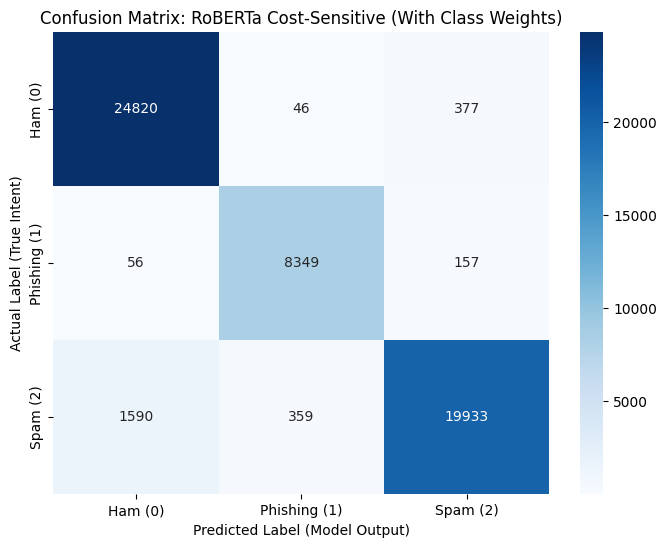

In [8]:
# ==========================================================================
# Evaluation & Plotting: RoBERTa Cost-Sensitive (Weighted) 
# ===========================================================================
target_names = ["Ham (0)", "Phishing (1)", "Spam (2)"]

print("\n" + "="*50)
print("ROBERTA COST-SENSITIVE (WEIGHTED) EVALUATION")
print("="*50)
print(classification_report(y_true_rob, y_pred_rob_weighted, target_names=target_names, digits=4))

print("\n3. Plotting the Confusion Matrix...")
cm_rob_weighted = confusion_matrix(y_true_rob, y_pred_rob_weighted)

plt.figure(figsize=(8, 6))
# Using a different color (e.g., Blues) to differentiate from the Baseline (Oranges)
sns.heatmap(cm_rob_weighted, annot=True, fmt='d', cmap='Blues', xticklabels=target_names, yticklabels=target_names)
plt.title('Confusion Matrix: RoBERTa Cost-Sensitive (With Class Weights)')
plt.ylabel('Actual Label (True Intent)')
plt.xlabel('Predicted Label (Model Output)')
plt.show()

#### 10.2. Establishing the RoBERTa Baseline (Unweighted)
[[go back to the topic]](#10-comparative-architecture-study-roberta)

To conduct a rigorous architectural comparison, we must evaluate RoBERTa in its standard, unweighted state. This establishes a true baseline, allowing us to build a comprehensive 2x2 comparative matrix: **DistilBERT (Baseline vs. Cost-Sensitive) against RoBERTa (Baseline vs. Cost-Sensitive)**.

This step is critical from an engineering perspective. Class weights optimized for a 66-million parameter architecture (DistilBERT) might act as overly aggressive penalties for a 125-million parameter architecture (RoBERTa), potentially degrading its performance artificially. By training the baseline model first, we successfully isolate the sheer architectural impact (parameter scale and attention mechanisms) from the loss function modifications.

In [3]:
# ===========================================================================
# 10.2 RoBERTa Baseline (Unweighted) Setup and Fine-Tuning
# ===========================================================================

print("1. Loading fresh RoBERTa base model for unweighted training...")
roberta_base_unweighted = AutoModelForSequenceClassification.from_pretrained(
    roberta_checkpoint, num_labels=3, id2label=id2label, label2id=label2id
)

print("2. Applying LoRA specifically for Baseline RoBERTa...")
roberta_lora_config_unweighted = LoraConfig(
    task_type=TaskType.SEQ_CLS, 
    r=8, 
    lora_alpha=16, 
    lora_dropout=0.05, 
    bias="none",
    target_modules=["query", "value"] 
)

roberta_model_unweighted = get_peft_model(roberta_base_unweighted, roberta_lora_config_unweighted)
roberta_model_unweighted.print_trainable_parameters()

# Using standard TrainingArguments and standard Trainer
roberta_args_unweighted = TrainingArguments(
    output_dir="./roberta-lora-baseline", 
    learning_rate=2e-4,
    per_device_train_batch_size=16, 
    per_device_eval_batch_size=16,
    num_train_epochs=2,
    weight_decay=0.01,
    eval_strategy="epoch",
    save_strategy="epoch",
    load_best_model_at_end=True,
    logging_steps=100,
)

# Standard Trainer from Hugging Face (No Cost-Sensitive loss)
roberta_trainer_unweighted = Trainer(
    model=roberta_model_unweighted,
    args=roberta_args_unweighted,
    train_dataset=tokenized_roberta["train"],
    eval_dataset=tokenized_roberta["test"],
    processing_class=roberta_tokenizer,
    data_collator=roberta_collator,
    compute_metrics=compute_metrics,
)

print("3. Starting RoBERTa Baseline (Unweighted) Training...")
roberta_trainer_unweighted.train()

print("4. Saving the final Baseline RoBERTa model...")
roberta_trainer_unweighted.save_model("./roberta-lora-baseline/final_model")
print("Training complete and model saved!")

1. Loading fresh RoBERTa base model for unweighted training...


Loading weights: 100%|██████████| 197/197 [00:00<00:00, 4488.96it/s]
[transformers] RobertaForSequenceClassification LOAD REPORT from: roberta-base
Key                        | Status     | 
---------------------------+------------+-
lm_head.dense.bias         | UNEXPECTED | 
lm_head.layer_norm.weight  | UNEXPECTED | 
lm_head.dense.weight       | UNEXPECTED | 
lm_head.bias               | UNEXPECTED | 
lm_head.layer_norm.bias    | UNEXPECTED | 
classifier.dense.bias      | MISSING    | 
classifier.out_proj.weight | MISSING    | 
classifier.dense.weight    | MISSING    | 
classifier.out_proj.bias   | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


2. Applying LoRA specifically for Baseline RoBERTa...
trainable params: 887,811 || all params: 125,535,750 || trainable%: 0.7072
3. Starting RoBERTa Baseline (Unweighted) Training...


c:\Users\aleja\OneDrive\Documentos\GitHub\Natural-Language-Processing\nlp_env\Lib\site-packages\torch\utils\data\dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)
[transformers] `use_return_dict` is deprecated! Use `return_dict` instead!


Epoch,Training Loss,Validation Loss,Accuracy,F1 Macro,Precision,Recall
1,0.188800,0.152596,0.950958,0.951010,0.957294,0.945377
2,0.130914,0.128432,0.959560,0.960001,0.961407,0.958700


c:\Users\aleja\OneDrive\Documentos\GitHub\Natural-Language-Processing\nlp_env\Lib\site-packages\torch\utils\data\dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


4. Saving the final Baseline RoBERTa model...
Training complete and model saved!


##### Confusion Matrix

In [ ]:
# ===========================================================================
# Confusion Matrix: RoBERTa Baseline (Unweighted)
# ===========================================================================
print("1. Evaluating Baseline RoBERTa on the unseen test set...")
predictions_rob_base = roberta_trainer_unweighted.predict(tokenized_roberta["test"])
y_pred_rob_base = np.argmax(predictions_rob_base.predictions, axis=-1)
y_true_rob = tokenized_roberta["test"]["label"]


ROBERTA BASELINE (NO CLASS WEIGHTS) EVALUATION
              precision    recall  f1-score   support

     Ham (0)     0.9579    0.9746    0.9662     25243
Phishing (1)     0.9682    0.9591    0.9636      8562
    Spam (2)     0.9582    0.9424    0.9502     21882

    accuracy                         0.9596     55687
   macro avg     0.9614    0.9587    0.9600     55687
weighted avg     0.9596    0.9596    0.9595     55687



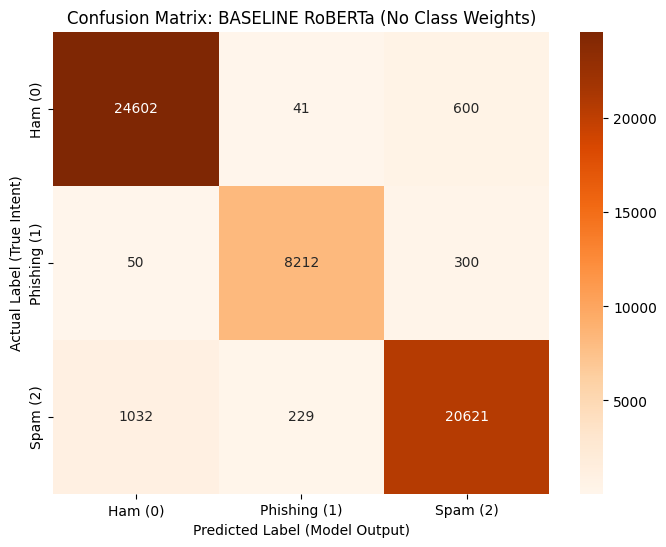


2. Generating the 2x2 Comparative Matrix...


,Architecture,Macro F1-Score,Phishing Recall,Training Time
0,DistilBERT (66M) - Baseline,96.79%,96.48%,~5.5 Hours
1,DistilBERT (66M) - Cost-Sensitive,96.81%,96.54%,~5.5 Hours
2,RoBERTa (125M) - Baseline,96.00%,95.91%,~13 Hours
3,RoBERTa (125M) - Cost-Sensitive,95.52%,97.51%,~13 Hours


In [9]:
# ===========================================================================
# Fast Evaluation Plotting (Uses variables already in RAM)
# ===========================================================================
target_names = ["Ham (0)", "Phishing (1)", "Spam (2)"]
print("\n" + "="*50)
print("ROBERTA BASELINE (NO CLASS WEIGHTS) EVALUATION")
print("="*50)
print(classification_report(y_true_rob, y_pred_rob_base, target_names=target_names, digits=4))

# 1. Generate Confusion Matrix for Baseline RoBERTa
cm_rob_base = confusion_matrix(y_true_rob, y_pred_rob_base)
plt.figure(figsize=(8, 6))
sns.heatmap(cm_rob_base, annot=True, fmt='d', cmap='Oranges', xticklabels=target_names, yticklabels=target_names)
plt.title('Confusion Matrix: BASELINE RoBERTa (No Class Weights)')
plt.ylabel('Actual Label (True Intent)')
plt.xlabel('Predicted Label (Model Output)')
plt.show()

# 2. Build the 2x2 Comparative Architectural Matrix
print("\n2. Generating the 2x2 Comparative Matrix...")
matrix_data = {
    'Architecture': [
        'DistilBERT (66M) - Baseline', 
        'DistilBERT (66M) - Cost-Sensitive',
        'RoBERTa (125M) - Baseline',
        'RoBERTa (125M) - Cost-Sensitive'
    ],
    'Macro F1-Score':  [0.9679, 0.9681, 0.9600, 0.9552], 
    'Phishing Recall': [0.9648, 0.9654, 0.9591, 0.9751], 
    'Training Time':   ['~5.5 Hours', '~5.5 Hours', '~13 Hours', '~13 Hours']
}

df_matrix = pd.DataFrame(matrix_data)
df_matrix_styled = df_matrix.style.format({
    'Macro F1-Score': "{:.2%}",
    'Phishing Recall': "{:.2%}"
}).set_caption("Table 2: 2x2 Comparative Matrix - Architecture vs. Loss Function")

display(df_matrix_styled)

#### 10.3. The 2x2 Matrix Analysis: Architecture vs. Loss Function
[[go back to the top]](#table-of-contents)

The 2x2 comparative matrix and subsequent confusion matrices yield critical engineering insights regarding model deployment under cost-sensitive constraints.

**1. The Double-Edged Sword of Asymmetric Weights:**
The cost-sensitive loss functioned exactly as mathematically intended: it pushed RoBERTa's Phishing Recall to an impressive 97.51%. However, applying DistilBERT's optimized weights (`[1.2, 4.0, 0.3]`) to a 125-million parameter architecture proved deeply destabilizing. To achieve this high recall, the weighted RoBERTa model collapsed its decision boundary between Spam and Ham. It incorrectly classified 1,590 Spam emails as Ham (flooding the user's inbox) and, ironically, the absolute number of critical failures (Phishing misclassified as Ham) actually increased from 50 (Baseline) to 56. This over-correction caused the model's overall Macro F1 to degrade to 95.52%.

**2. The Definitive Conclusion (DistilBERT's Superiority):**
This analysis definitively establishes **DistilBERT Cost-Sensitive as the superior model for real-world deployment**. DistilBERT successfully absorbed the asymmetric weights without losing structural integrity, maintaining a highly balanced Macro F1 (96.81%) while minimizing critical security breaches (allowing only 35 Phishing emails into the inbox, compared to RoBERTa's 56). 

Ultimately, DistilBERT achieves a far more robust security posture while operating at double the speed and half the parameter count, proving that massive architectural scale (RoBERTa) cannot compensate for data starvation on a 10% subsample.

### 11. Domain Adaptation: Testing Model Generalization
[[go back to the top]](#table-of-contents)

A common failure mode in machine learning security systems is dataset overfitting, where the model learns surface patterns from the training data (such as corporate email signatures) instead of the underlying semantics of a threat.

To assess the robustness of our contextual embeddings, we conduct a domain adaptation test. Specifically, we evaluate the previously fine-tuned DistilBERT model on a completely different domain: **SMS messages**, using the public SMS Spam Collection dataset.

If the model can correctly identify malicious intent in short, informal messages without being trained on this format, it provides strong evidence of true semantic generalization rather than reliance on dataset-specific artifacts.

In [ ]:
# ===========================================================================
# 11.1 Domain Adaptation: Evaluating DistilBERT on SMS Data
# ===========================================================================
print("1. Loading Out-of-Domain Dataset (SMS Spam Collection)...")
# Load SMS dataset from Hugging Face hub
sms_dataset = load_dataset("sms_spam", split="train")

# The SMS dataset has labels: 0 for Ham, 1 for Spam. 
# We will map our model's predictions to see if it catches the SMS Spam.
sms_texts = sms_dataset["sms"]
sms_labels = sms_dataset["label"] # 0: Ham, 1: Spam

print("2. Loading the fine-tuned DistilBERT (Cost-Sensitive)...")
model_checkpoint = "distilbert-base-uncased"
tokenizer = AutoTokenizer.from_pretrained(model_checkpoint)

base_model = AutoModelForSequenceClassification.from_pretrained(
    model_checkpoint, num_labels=3
)
lora_path = "./artifacts/distilbert-lora-phishing/checkpoint-5570" # Adjust if needed
domain_model = PeftModel.from_pretrained(base_model, lora_path)

# Ensure evaluation mode
domain_model.eval()
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
domain_model.to(device)

print("3. Running Inference on Unseen SMS Domain...")
predictions = []

# Process in small batches to avoid memory issues
batch_size = 32
for i in range(0, len(sms_texts), batch_size):
    batch_texts = sms_texts[i:i+batch_size]
    inputs = tokenizer(batch_texts, padding=True, truncation=True, max_length=256, return_tensors="pt").to(device)
    
    with torch.no_grad():
        outputs = domain_model(**inputs)
        preds = torch.argmax(outputs.logits, dim=-1)
        predictions.extend(preds.cpu().numpy())

# 4. Map the predictions for evaluation
# Our model: 0=Ham, 1=Phish, 2=Spam. SMS dataset: 0=Ham, 1=Spam.
# We will consider both '1' (Phish) and '2' (Spam) as 'Malicious' to match the SMS 'Spam' label.
mapped_predictions = [1 if p in [1, 2] else 0 for p in predictions]

print("\n--- Domain Adaptation Classification Report (SMS Data) ---")
print(classification_report(sms_labels, mapped_predictions, target_names=["Legitimate (Ham)", "Malicious (Spam/Phish)"]))

### 12. Zero-Shot Prompting
[[go back to the top]](#table-of-contents)

Fine-tuning requires large annotated datasets and significant computational resources, as observed with DistilBERT and RoBERTa. A modern alternative is **Zero-Shot Classification**, which leverages large instruction-tuned models without task-specific training.

In this section, we evaluate whether an off-the-shelf **Natural Language Inference (NLI)** model can classify phishing emails using only descriptive class labels as prompts, without any gradient updates or exposure to our dataset.

The evaluation focuses on the most challenging adversarial samples, specifically the blind spots identified in [[Section 9]](#9-error-analysis-did-contextual-embeddings-solve-the-blind-spots), to test whether zero-shot reasoning can handle cases where fine-tuned models struggled.

In [ ]:
# ===========================================================================
# 12.1 Zero-Shot Classification using Hugging Face Pipeline (Quantitative)
# ===========================================================================
# 1. Build a stratified 5000-email subset of the test set
print("Building stratified evaluation subset...")
# Assuming X_test and y_test are available in your environment from previous splits
test_df = pd.DataFrame({
    'text':  X_test.values,
    'label': y_test.values
})

# Stratified sampling preserves class proportions (Ham/Phishing/Spam)
from sklearn.model_selection import train_test_split
zero_shot_subset, _ = train_test_split(
    test_df,
    train_size=5000,
    random_state=42,
    stratify=test_df['label']
)
zero_shot_subset = zero_shot_subset.reset_index(drop=True)

print(f"Subset size: {len(zero_shot_subset)}")
print("Class distribution in subset:")
print(zero_shot_subset['label'].value_counts(normalize=True).sort_index() * 100)


# 2. Load the zero-shot classification pipeline
print("\nLoading facebook/bart-large-mnli (this may download ~1.6GB on first run)...")
zero_shot_classifier = pipeline(
    "zero-shot-classification",
    model="facebook/bart-large-mnli",
    device=-1   # force CPU; change to 0 if you have a GPU
)

# 3. Define candidate labels with descriptive hypotheses
# The exact wording matters: NLI models are sensitive to how labels are phrased
candidate_labels = [
    "a legitimate personal or business email",
    "a phishing attempt designed to steal personal information",
    "an unsolicited spam or promotional message"
]

# Map descriptive labels back to our integer label space
label_mapping = {
    candidate_labels[0]: 0,  # Ham
    candidate_labels[1]: 1,  # Phishing
    candidate_labels[2]: 2,  # Spam
}


# 4. Run inference 
print("\nRunning zero-shot classification on 5,000 emails...")
print("This will take roughly 30-60 minutes on CPU.\n")

predictions_zero_shot = []
start_time = time.time()

for text in tqdm(zero_shot_subset['text'].values, desc="Classifying"):
    # Use Hugging Face's native token-level truncation instead of slicing strings manually
    result = zero_shot_classifier(
        str(text), 
        candidate_labels, 
        multi_label=False, 
        truncation=True, 
        max_length=1024
    )
    # The pipeline returns labels sorted by confidence, top one first
    top_label = result['labels'][0]
    predictions_zero_shot.append(label_mapping[top_label])

elapsed_min = (time.time() - start_time) / 60
print(f"\nInference completed in {elapsed_min:.1f} minutes.")


# 5. Evaluate
y_true_zs = zero_shot_subset['label'].values
y_pred_zs = np.array(predictions_zero_shot)

# Define target_names to prevent NameError during evaluation
target_names = ["Ham", "Phishing", "Spam"]

print("\n" + "=" * 50)
print("ZERO-SHOT CLASSIFICATION REPORT (BART-MNLI)")
print("=" * 50)
print(classification_report(y_true_zs, y_pred_zs, target_names=target_names, digits=4))


# 6. Confusion matrix
cm_zs = confusion_matrix(y_true_zs, y_pred_zs)

plt.figure(figsize=(8, 6))
sns.heatmap(cm_zs, annot=True, fmt='d', cmap='Purples',
            xticklabels=target_names, yticklabels=target_names)
plt.title('Confusion Matrix: Zero-shot BART-MNLI (no fine-tuning)')
plt.ylabel('Actual Label (True Intent)')
plt.xlabel('Predicted Label (Model Output)')
plt.show()


# 7. Save predictions for later cross-comparison
os.makedirs('artifacts/predictions', exist_ok=True)
np.save('artifacts/predictions/y_pred_zero_shot_bart.npy', y_pred_zs)
np.save('artifacts/predictions/y_true_zero_shot_subset.npy',  y_true_zs)
print("\nPredictions saved to artifacts/predictions/")

##### Session Restore
[[go back to the top]](#table-of-contents)

In [2]:
# ===========================================================================
# SESSION RESTORE / SETUP BLOCK FOR ROBERTA
# Run this cell if the kernel restarts before running Section 10.2
# ===========================================================================
print("1. Loading RoBERTa variables and configurations...")
roberta_checkpoint = "roberta-base"
id2label = {0: "Ham", 1: "Phishing", 2: "Spam"}
label2id = {"Ham": 0, "Phishing": 1, "Spam": 2}
OPTIMAL_MAX_LENGTH = 256 

os.environ["HF_HUB_DISABLE_SYMLINKS_WARNING"] = "1"

# Initialize RoBERTa specific tokenizer and collator
roberta_tokenizer = AutoTokenizer.from_pretrained(roberta_checkpoint)
roberta_collator = DataCollatorWithPadding(tokenizer=roberta_tokenizer)

def compute_metrics(pred):
    labels = pred.label_ids
    preds = pred.predictions.argmax(-1)
    precision, recall, f1, _ = precision_recall_fscore_support(labels, preds, average='macro', zero_division=0)
    acc = accuracy_score(labels, preds)
    return {'accuracy': acc, 'f1_macro': f1, 'precision': precision, 'recall': recall}

print("2. Rebuilding the tokenized datasets specifically for RoBERTa...")
df = pd.read_csv('data/df_preprocessed_final.csv').dropna(subset=['text', 'label'])

X = df['text'].astype(str)
y = df['label'].astype(int)

# Exact same split as before to prevent Data Leakage
X_train_full, X_test, y_train_full, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
X_train_sub, _, y_train_sub, _ = train_test_split(X_train_full, y_train_full, train_size=0.10, random_state=42, stratify=y_train_full)

roberta_dataset = DatasetDict({
    'train': Dataset.from_dict({'text': X_train_sub.values, 'label': y_train_sub.values}),
    'test': Dataset.from_dict({'text': X_test.values, 'label': y_test.values})
})

def roberta_tokenize(examples):
    return roberta_tokenizer(examples["text"], truncation=True, max_length=OPTIMAL_MAX_LENGTH)

print(f"Tokenizing datasets with RoBERTa tokenizer (max_length={OPTIMAL_MAX_LENGTH})...")
tokenized_roberta = roberta_dataset.map(roberta_tokenize, batched=True)
tokenized_roberta = tokenized_roberta.remove_columns(["text"])
tokenized_roberta.set_format("torch")

print("RoBERTa Session successfully restored. Ready to proceed with Section 10.2.")

1. Loading RoBERTa variables and configurations...
2. Rebuilding the tokenized datasets specifically for RoBERTa...
Tokenizing datasets with RoBERTa tokenizer (max_length=256)...


Map: 100%|██████████| 55687/55687 [00:08<00:00, 6955.34 examples/s]

RoBERTa Session successfully restored. Ready to proceed with Section 10.2.
